In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Configurar matplotlib para visualizaciones en español
plt.rcParams['font.size'] = 10


In [2]:
# ============================================
# 1. DEFINIR Y AJUSTAR PCA
# ============================================

# Crear instancia de PCA con 2 componentes principales
n_components = 2
pca = PCA(n_components=n_components)

print(f"PCA configurado con {n_components} componentes principales")
print(f"PCA: {pca}")


PCA configurado con 2 componentes principales
PCA: PCA(n_components=2)


In [3]:
# ============================================
# 2. PREPARAR LOS DATOS
# ============================================

# Cargar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Agregar outliers artificiales (flores con características extremas)
np.random.seed(42)
num_outliers = 10
outliers = np.random.uniform(-4, 4, size=(num_outliers, 4))

# Combinar datos normales con outliers
X_with_outliers = np.vstack([X_scaled, outliers])
y_labels = np.hstack([np.zeros(len(X_scaled)), np.ones(num_outliers)])  # 0: normal, 1: outlier

print(f"Datos de entrenamiento: {X_with_outliers.shape}")
print(f"Etiquetas: {y_labels.shape}")
print(f"Número de outliers: {num_outliers}")


Datos de entrenamiento: (160, 4)
Etiquetas: (160,)
Número de outliers: 10


¡PCA ajustado y transformación completada!

Varianza explicada por cada componente:
  Componente 1: 72.96% (Acumulada: 72.96%)
  Componente 2: 22.85% (Acumulada: 95.81%)


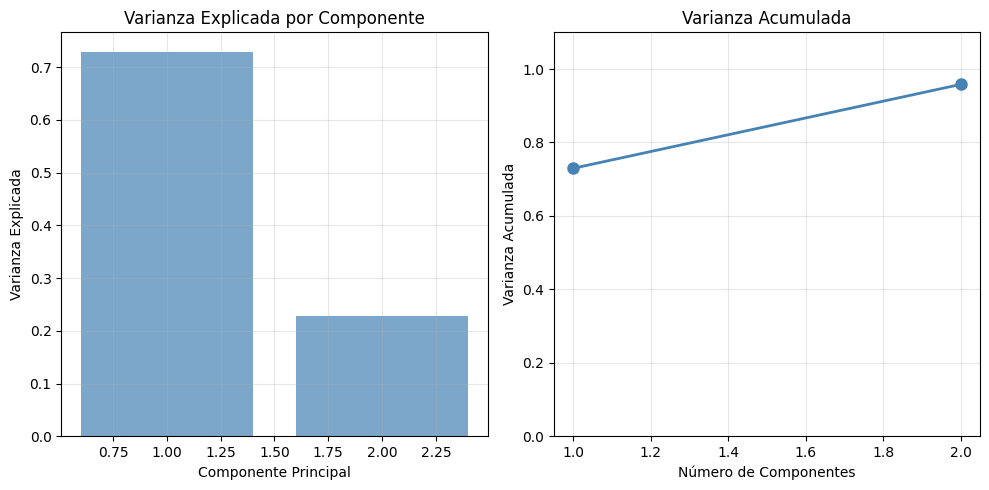

In [4]:
# ============================================
# 3. AJUSTAR PCA CON LOS DATOS
# ============================================

# Ajustar PCA solo con datos normales (sin outliers)
X_normal = X_scaled
pca.fit(X_normal)

# Transformar todos los datos al espacio de componentes principales
X_pca = pca.transform(X_with_outliers)

# Reconstruir los datos desde el espacio PCA
X_reconstructed = pca.inverse_transform(X_pca)

print("¡PCA ajustado y transformación completada!")

# Mostrar varianza explicada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"\nVarianza explicada por cada componente:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"  Componente {i+1}: {var:.2%} (Acumulada: {cum_var:.2%})")

# Visualizar varianza explicada
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='steelblue')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componente')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.1])

plt.tight_layout()
plt.show()


In [5]:
# ============================================
# 4. DETECTAR OUTLIERS
# ============================================

# Calcular el error de reconstrucción (MSE) para cada muestra
reconstruction_errors = np.mean((X_with_outliers - X_reconstructed) ** 2, axis=1)

print(f"Error de reconstrucción - Min: {reconstruction_errors.min():.4f}, "
      f"Max: {reconstruction_errors.max():.4f}, "
      f"Media: {reconstruction_errors.mean():.4f}")

# Calcular umbral (percentil 95 de los datos normales)
normal_errors = reconstruction_errors[y_labels == 0]
threshold = np.percentile(normal_errors, 95)
print(f"Umbral de detección (percentil 95): {threshold:.4f}")

# Identificar outliers basado en el error de reconstrucción
predicted_outliers = reconstruction_errors > threshold

print(f"\nOutliers detectados: {predicted_outliers.sum()}")
print(f"Outliers reales: {y_labels.sum()}")

# Calcular precisión y recall
true_positives = np.sum((predicted_outliers) & (y_labels == 1))
false_positives = np.sum((predicted_outliers) & (y_labels == 0))
false_negatives = np.sum((~predicted_outliers) & (y_labels == 1))

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

print(f"\nPrecisión: {precision:.2%}")
print(f"Recall: {recall:.2%}")


Error de reconstrucción - Min: 0.0002, Max: 9.8158, Media: 0.2666
Umbral de detección (percentil 95): 0.1434

Outliers detectados: 18
Outliers reales: 10.0

Precisión: 55.56%
Recall: 100.00%


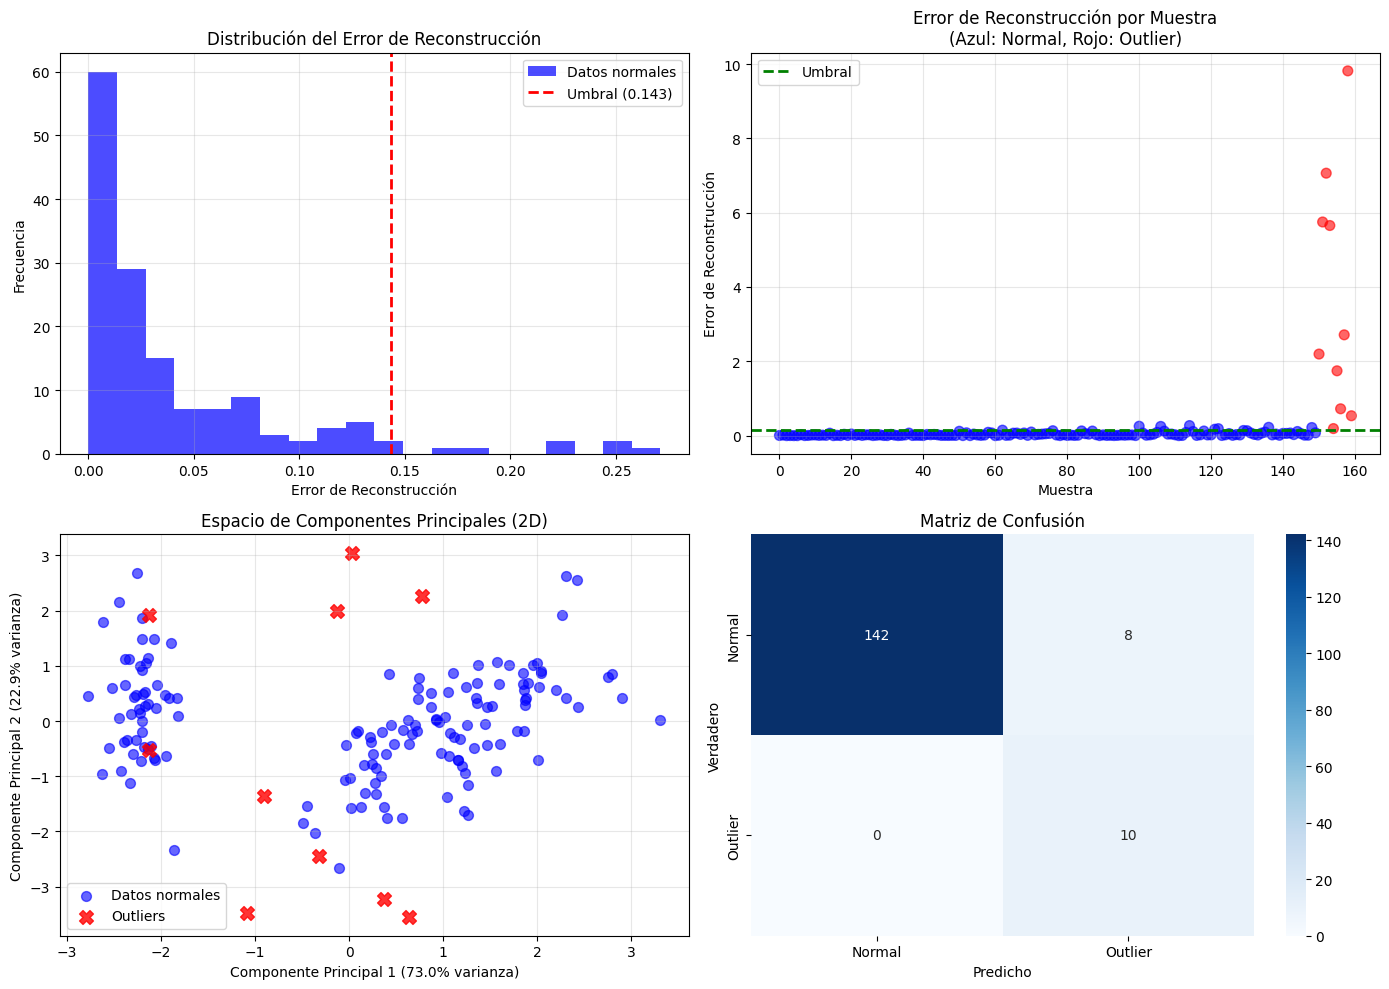

In [6]:
# ============================================
# 5. VISUALIZACIONES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de errores de reconstrucción
ax = axes[0, 0]
ax.hist(normal_errors, bins=20, alpha=0.7, label='Datos normales', color='blue')
ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Umbral ({threshold:.3f})')
ax.set_xlabel('Error de Reconstrucción')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del Error de Reconstrucción')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Error de reconstrucción por muestra
ax = axes[0, 1]
colors = ['blue' if y == 0 else 'red' for y in y_labels]
ax.scatter(range(len(reconstruction_errors)), reconstruction_errors, c=colors, alpha=0.6, s=50)
ax.axhline(threshold, color='green', linestyle='--', linewidth=2, label=f'Umbral')
ax.set_xlabel('Muestra')
ax.set_ylabel('Error de Reconstrucción')
ax.set_title('Error de Reconstrucción por Muestra\n(Azul: Normal, Rojo: Outlier)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Espacio de componentes principales (2D)
ax = axes[1, 0]
ax.scatter(X_pca[y_labels == 0, 0], X_pca[y_labels == 0, 1], 
           c='blue', alpha=0.6, s=50, label='Datos normales')
ax.scatter(X_pca[y_labels == 1, 0], X_pca[y_labels == 1, 1], 
           c='red', alpha=0.8, s=100, marker='X', label='Outliers')
ax.set_xlabel(f'Componente Principal 1 ({explained_variance[0]:.1%} varianza)')
ax.set_ylabel(f'Componente Principal 2 ({explained_variance[1]:.1%} varianza)')
ax.set_title('Espacio de Componentes Principales (2D)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Matriz de confusión
ax = axes[1, 1]
cm = confusion_matrix(y_labels, predicted_outliers)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Normal', 'Outlier'], 
            yticklabels=['Normal', 'Outlier'])
ax.set_ylabel('Verdadero')
ax.set_xlabel('Predicho')
ax.set_title('Matriz de Confusión')

plt.tight_layout()
plt.show()


In [7]:
# ============================================
# 6. DEMOSTRACIÓN CON NUEVAS MUESTRAS
# ============================================

print("=" * 60)
print("EJEMPLOS DE DETECCIÓN DE OUTLIERS")
print("=" * 60)

# Función para detectar si una nueva muestra es un outlier
def detect_outlier(sample, pca_model, scaler_model, threshold):
    """
    Detecta si una muestra es un outlier usando PCA
    Args:
        sample: numpy array con las características (sin normalizar)
        pca_model: modelo PCA ajustado
        scaler_model: scaler ajustado para normalización
        threshold: umbral de error de reconstrucción
    Returns:
        is_outlier: booleano
        error: error de reconstrucción
    """
    # Normalizar la muestra
    sample_scaled = scaler_model.transform(sample.reshape(1, -1))
    
    # Transformar al espacio PCA
    sample_pca = pca_model.transform(sample_scaled)
    
    # Reconstruir desde el espacio PCA
    sample_reconstructed = pca_model.inverse_transform(sample_pca)
    
    # Calcular error de reconstrucción
    error = np.mean((sample_scaled - sample_reconstructed) ** 2)
    is_outlier = error > threshold
    
    return is_outlier, error

# Ejemplos
print("\n1. Muestra NORMAL (del dataset de entrenamiento):")
sample_normal = X_scaled[0]
is_outlier, error = detect_outlier(sample_normal, pca, scaler, threshold)
print(f"   Características: {sample_normal}")
print(f"   Error: {error:.4f}")
print(f"   ¿Es outlier?: {'SÍ' if is_outlier else 'NO'}")

print("\n2. Muestra OUTLIER (artificial extrema):")
sample_outlier = outliers[0]
is_outlier, error = detect_outlier(sample_outlier, pca, scaler, threshold)
print(f"   Características: {sample_outlier}")
print(f"   Error: {error:.4f}")
print(f"   ¿Es outlier?: {'SÍ' if is_outlier else 'NO'}")

print("\n3. Muestra AMBIGUA (ligeramente fuera de rango):")
sample_ambigua = np.array([3.5, 3.5, 3.5, 3.5])  # valores altos pero no extremos
is_outlier, error = detect_outlier(sample_ambigua, pca, scaler, threshold)
print(f"   Características: {sample_ambigua}")
print(f"   Error: {error:.4f}")
print(f"   ¿Es outlier?: {'SÍ' if is_outlier else 'NO'}")


EJEMPLOS DE DETECCIÓN DE OUTLIERS

1. Muestra NORMAL (del dataset de entrenamiento):
   Características: [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
   Error: 1.4677
   ¿Es outlier?: SÍ

2. Muestra OUTLIER (artificial extrema):
   Características: [-1.00367905  3.60571445  1.85595153  0.78926787]
   Error: 9.1154
   ¿Es outlier?: SÍ

3. Muestra AMBIGUA (ligeramente fuera de rango):
   Características: [3.5 3.5 3.5 3.5]
   Error: 4.5680
   ¿Es outlier?: SÍ
